# Thermosensibilité à la CHALEUR (climatisation) — notebook exploratoire

Pendant côté chaud de l'analyse du froid. On cherche à savoir si, quand il fait **chaud**, la consommation électrique **augmente** avec la température (climatisation, ventilation), et comment cet effet varie d'une région à l'autre.

**Hypothèses de départ :**
- le signal clim est **faible en France** (parc de climatiseurs encore limité), et **noyé** si on regarde tout l'été indistinctement — il faut isoler les *vrais jours chauds* ;
- il devrait être **beaucoup plus marqué dans le sud** (PACA, Occitanie) que dans le nord/ouest ;
- la pente attendue est **positive** (plus chaud → plus de conso), à l'inverse du gradient de chauffage.

On réutilise le module `thermosensibilite.py` pour le chargement et l'agrégation, puis on écrit ici la logique spécifique au chaud (exploratoire).

## 1. Chargement

In [25]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

import thermosensibilite as th

CONSO_PATH = 'conso_journaliere_regionale_2013_2026.csv'
TEMP_PATH  = 'temperature-quotidienne-regionale.csv'

conso_reg, temp_reg = th.charger_donnees(CONSO_PATH, TEMP_PATH)
national = th.construire_national(conso_reg, temp_reg, ponderation='population')
print(national['Date'].min().date(), '->', national['Date'].max().date(), '|', len(national), 'jours')

2016-01-01 -> 2026-05-30 | 3390 jours


## 2. La courbe en U : chauffage à gauche, climatisation à droite

Avant toute régression, on visualise la relation complète conso ↔ température sur toute l'année. On s'attend à une courbe en **U** (ou en crosse de hockey asymétrique) : conso qui chute quand la température monte (fin du chauffage), un plateau de confort, puis une **remontée** aux fortes chaleurs (clim). C'est cette branche droite qui nous intéresse ici.

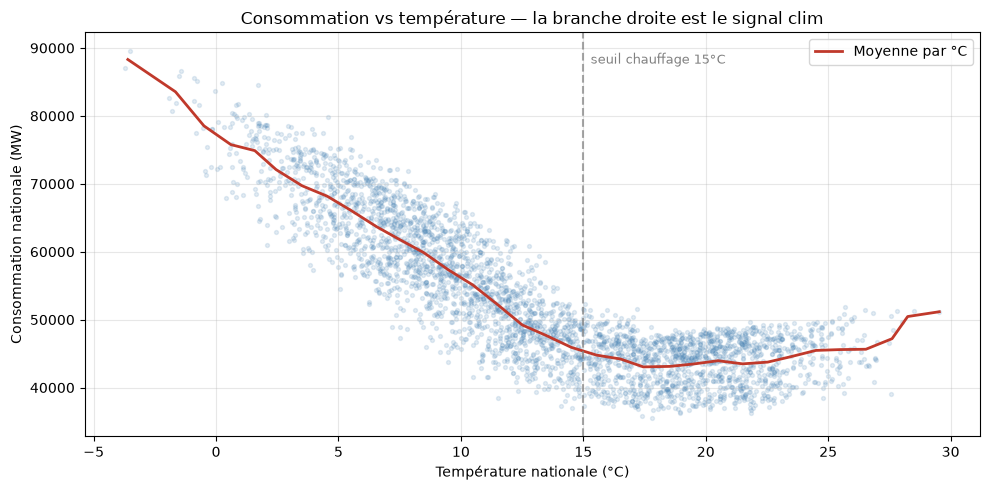

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(national['temp'], national['conso_mw'], s=8, alpha=0.15, color='steelblue')

# moyenne mobile par tranche de température pour faire ressortir la forme
bins = np.arange(-5, 35, 1)
national['temp_bin'] = pd.cut(national['temp'], bins)
moyennes = national.groupby('temp_bin', observed=True).agg(
    t=('temp', 'mean'), c=('conso_mw', 'mean')).dropna()
ax.plot(moyennes['t'], moyennes['c'], color='#c0392b', lw=2, label='Moyenne par °C')

ax.axvline(15, ls='--', color='gray', alpha=0.7)
ax.text(15.3, ax.get_ylim()[1]*0.95, 'seuil chauffage 15°C', color='gray', fontsize=9)
ax.set_xlabel('Température nationale (°C)')
ax.set_ylabel('Consommation nationale (MW)')
ax.set_title('Consommation vs température — la branche droite est le signal clim')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Le point bas de la courbe (le minimum de consommation) indique la **température de confort** où ni chauffage ni clim ne domine — en général autour de 18-20°C en France. Au-delà, la remontée, si elle existe, est l'effet climatisation.

## 3. Quel indicateur de température pour le chaud : TMoy ou TMax ?

Le chauffage et la climatisation ne réagissent pas à la même chose. Le chauffage tourne une bonne partie de la journée et de la nuit : la température **moyenne** en est un bon proxy (c'est ce qu'utilise RTE). La climatisation, elle, se déclenche sur le **pic de chaleur de l'après-midi** — une journée à TMoy = 20 °C peut être uniformément douce (pas de clim) ou avoir une nuit fraîche et un après-midi à 32 °C (clim à fond). La moyenne écrase ces deux cas ; la **température maximale** (`temp_max`) les distingue.

Plutôt que de trancher a priori, on laisse les données décider : on calcule le gradient clim région par région avec les deux indicateurs et on compare le **R²**. Attention, les seuils ne sont pas comparables — TMax tourne ~5-7 °C au-dessus de TMoy, donc un jour chaud correspond à TMoy > 20 °C **ou** TMax > 27 °C environ.

In [37]:
# Comparaison TMoy vs TMax pour le signal clim, région par région
reg_cmp = pd.merge(
    conso_reg[['Date', 'Région', 'region_norm', 'conso_mw']],
    temp_reg[['Date', 'region_norm', 'temp', 'temp_max']],
    on=['Date', 'region_norm'], how='inner')
reg_cmp['weekday'] = reg_cmp['Date'].dt.weekday

def _grad_indicateur(data, col, seuil, min_jours=30):
    sub = data[data[col] > seuil]
    if len(sub) < min_jours:
        return np.nan, np.nan, len(sub)
    X = pd.concat([sub[[col]], pd.get_dummies(sub['weekday'], prefix='wd', drop_first=True)],
                  axis=1).astype(float)
    X = sm.add_constant(X)
    m = sm.OLS(sub['conso_mw'], X).fit()
    return m.params[col], m.rsquared, len(sub)

SEUIL_TMOY, SEUIL_TMAX = 20.0, 27.0
lignes = []
for region, g in reg_cmp.groupby('Région', observed=True):
    g_moy, r_moy, n_moy = _grad_indicateur(g, 'temp', SEUIL_TMOY)
    g_max, r_max, n_max = _grad_indicateur(g, 'temp_max', SEUIL_TMAX)
    gagnant = ('TMax' if (r_max or -1) > (r_moy or -1) else 'TMoy') \
              if not (np.isnan(r_moy) or np.isnan(r_max)) else '—'
    lignes.append({'Région': region,
                   'grad_TMoy': g_moy, 'R2_TMoy': r_moy, 'n_TMoy': n_moy,
                   'grad_TMax': g_max, 'R2_TMax': r_max, 'n_TMax': n_max,
                   'meilleur_R2': gagnant})

comparaison = pd.DataFrame(lignes)
comparaison.round(2)

,Région,grad_TMoy,R2_TMoy,n_TMoy,grad_TMax,R2_TMax,n_TMax,meilleur_R2
0,Auvergne-Rhône-Alpes,37.04,0.55,682,20.86,0.52,629,TMoy
1,Bourgogne-Franche-Comté,2.40,0.48,623,4.53,0.46,575,TMoy
2,Bretagne,11.68,0.83,201,8.03,0.83,129,TMoy
3,Centre-Val de Loire,20.87,0.55,588,14.42,0.57,491,TMax
4,Grand Est,16.91,0.47,502,9.26,0.49,465,TMax
5,Hauts-de-France,10.72,0.42,297,-1.40,0.41,200,TMoy
6,Normandie,14.18,0.49,248,5.41,0.43,179,TMoy
7,Nouvelle-Aquitaine,58.62,0.66,770,41.51,0.63,556,TMoy
8,Occitanie,99.89,0.78,959,71.77,0.63,767,TMoy
9,Pays de la Loire,17.94,0.72,584,11.67,0.74,431,TMax


In [38]:
# Synthèse : quel indicateur gagne le plus souvent ?
valides = comparaison[comparaison['meilleur_R2'] != '—']
print(valides['meilleur_R2'].value_counts())
print()
print(f"R² moyen TMoy : {valides['R2_TMoy'].mean():.3f}")
print(f"R² moyen TMax : {valides['R2_TMax'].mean():.3f}")

meilleur_R2
TMoy    8
TMax    4
Name: count, dtype: int64

R² moyen TMoy : 0.597
R² moyen TMax : 0.567


**Lecture** : si `TMax` l'emporte dans la majorité des régions et que son R² moyen est plus élevé, c'est la confirmation empirique que la clim se pilote sur le pic de chaleur, pas sur la moyenne du jour. Dans ce cas, il est justifié de basculer toute l'analyse chaude sur `temp_max` (avec un seuil recalibré, à trouver par un balayage sur `temp_max` : 24, 26, 28, 30 °C). Si les deux se valent, on peut garder `TMoy` par simplicité et cohérence avec la partie froid.

Note : la partie **froid garde `TMoy`** dans tous les cas — la distinction ne concerne que le chaud.

## 4. Fonction de gradient chaud

Symétrique de la version froid, mais on garde les jours **au-dessus** d'un seuil et on attend une pente **positive**. On contrôle toujours le jour de semaine.

In [29]:
def gradient_chaud(data, seuil, min_obs=30):
    """Régression conso ~ temp + weekday sur les jours au-dessus du seuil (signal clim).
    Retourne (pente MW/°C, R², n). Pente attendue positive."""
    g = data[data['temp'] > seuil]
    if len(g) < min_obs:
        return np.nan, np.nan, len(g)
    X = pd.concat([g[['temp']], pd.get_dummies(g['weekday'], prefix='wd', drop_first=True)],
                  axis=1).astype(float)
    X = sm.add_constant(X)
    m = sm.OLS(g['conso_mw'], X, missing='drop').fit()
    return m.params['temp'], m.rsquared, len(g)

## 5. À partir de quelle température le signal clim émerge-t-il ?

On balaie le seuil chaud au niveau national. On s'attend à voir la pente positive **apparaître puis s'accentuer** aux fortes températures — signe que la clim ne se déclenche massivement que lors des pics.

In [30]:
print('Seuil     Gradient       R²      n jours')
for seuil in [18, 20, 22, 24, 26, 28]:
    pente, r2, n = gradient_chaud(national, seuil)
    if np.isnan(pente):
        print(f'> {seuil}°C   (trop peu de jours : n={n})')
    else:
        print(f'> {seuil}°C   {pente:+8.0f} MW/°C   {r2:.3f}   {n}')

Seuil     Gradient       R²      n jours
> 18°C       +299 MW/°C   0.641   935
> 20°C       +335 MW/°C   0.631   612
> 22°C       +495 MW/°C   0.600   298
> 24°C       +375 MW/°C   0.579   113
> 26°C   (trop peu de jours : n=27)
> 28°C   (trop peu de jours : n=3)


**Lecture** : si la pente grandit avec le seuil, c'est la **convexité** de la réponse clim (chaque degré supplémentaire au-dessus de 25-30°C sollicite bien plus de climatiseurs que les premiers degrés de chaleur). Attention : `n` chute vite aux seuils élevés — au-delà de 28°C on a trop peu de jours au niveau national pour un chiffre fiable. Un seuil de **22 à 24°C** est un bon compromis signal/robustesse.

## 6. Gradient chaud par région + fiabilité

Le cœur de la comparaison régionale. On mesure la pente positive région par région, **et** on compte le nombre de jours chauds : c'est crucial ici, car les régions du nord ont très peu de jours au-dessus du seuil, donc leur estimation est fragile (à afficher, pas à masquer).

In [31]:
SEUIL_CHAUD = 22.0   # °C
MIN_JOURS   = 30     # en-dessous, on considère l'estimation régionale non fiable

reg = pd.merge(
    conso_reg[['Date', 'Région', 'region_norm', 'conso_mw']],
    temp_reg[['Date', 'region_norm', 'temp']],
    on=['Date', 'region_norm'], how='inner')
reg['weekday'] = reg['Date'].dt.weekday

lignes = []
for region, g in reg.groupby('Région', observed=True):
    sub = g[g['temp'] > SEUIL_CHAUD]
    n = len(sub)
    conso_moy = sub['conso_mw'].mean() if n else np.nan
    if n < MIN_JOURS:
        lignes.append({'Région': region, 'gradient_MW_par_C': np.nan,
                       'gradient_pct_par_C': np.nan, 'r2': np.nan,
                       'jours_chauds': n, 'fiable': False})
        continue
    X = pd.concat([sub[['temp']], pd.get_dummies(sub['weekday'], prefix='wd', drop_first=True)],
                  axis=1).astype(float)
    X = sm.add_constant(X)
    m = sm.OLS(sub['conso_mw'], X).fit()
    pente = m.params['temp']
    lignes.append({'Région': region, 'gradient_MW_par_C': pente,
                   'gradient_pct_par_C': 100 * pente / conso_moy,
                   'r2': m.rsquared, 'jours_chauds': n, 'fiable': True})

chaud_regions = pd.DataFrame(lignes).sort_values('gradient_MW_par_C', ascending=False)
chaud_regions.round(2)

,Région,gradient_MW_par_C,gradient_pct_par_C,r2,jours_chauds,fiable
10,Provence-Alpes-Côte d'Azur,114.11,2.68,0.76,829,True
8,Occitanie,105.12,2.73,0.76,643,True
11,Île-de-France,89.19,1.43,0.47,319,True
7,Nouvelle-Aquitaine,58.12,1.37,0.71,416,True
0,Auvergne-Rhône-Alpes,46.44,0.74,0.52,411,True
4,Grand Est,29.77,0.70,0.46,238,True
3,Centre-Val de Loire,20.44,1.20,0.59,274,True
9,Pays de la Loire,17.89,0.72,0.74,292,True
6,Normandie,15.83,0.63,0.39,98,True
1,Bourgogne-Franche-Comté,13.42,0.69,0.44,342,True


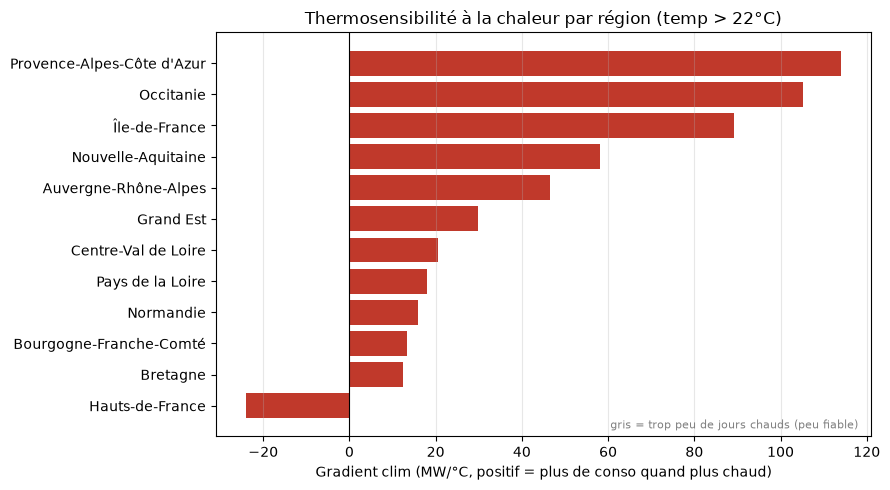

In [32]:
# Visualisation : gradient chaud par région, en grisant les régions non fiables
d = chaud_regions.dropna(subset=['gradient_MW_par_C']).sort_values('gradient_MW_par_C')
couleurs = ['#c0392b' if f else '#cccccc' for f in d['fiable']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(d['Région'], d['gradient_MW_par_C'], color=couleurs)
ax.set_xlabel('Gradient clim (MW/°C, positif = plus de conso quand plus chaud)')
ax.set_title(f'Thermosensibilité à la chaleur par région (temp > {SEUIL_CHAUD:.0f}°C)')
ax.axvline(0, color='black', lw=0.8)
ax.grid(axis='x', alpha=0.3)
# note fiabilité
ax.text(0.98, 0.02, 'gris = trop peu de jours chauds (peu fiable)',
        transform=ax.transAxes, ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

**Lecture attendue** : PACA et Occitanie loin devant (Méditerranée, forte pénétration de la clim), le nord et l'ouest proches de zéro. Les régions grisées (peu de jours > seuil) ne doivent pas être interprétées : un gradient calculé sur 40 jours n'a pas la robustesse de celui du sud sur 400+ jours.

## 7. Comparaison froid vs chaud, région par région

On met côte à côte les deux thermosensibilités pour chaque région : à quel point elle réagit au froid (chauffage) et à la chaleur (clim). Deux logiques géographiques différentes.

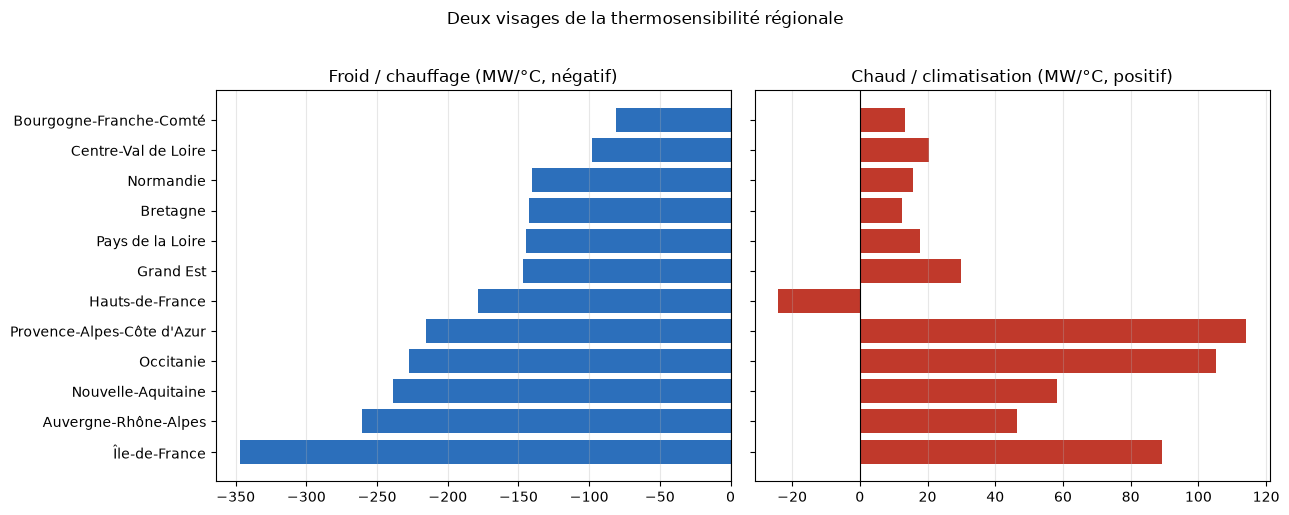

,Région,froid_MW_par_C,chaud_MW_par_C,fiable
7,Île-de-France,-346.7,89.2,True
8,Auvergne-Rhône-Alpes,-260.6,46.4,True
2,Nouvelle-Aquitaine,-238.8,58.1,True
1,Occitanie,-227.6,105.1,True
3,Provence-Alpes-Côte d'Azur,-215.6,114.1,True
10,Hauts-de-France,-178.3,-24.1,True
11,Grand Est,-146.8,29.8,True
4,Pays de la Loire,-144.7,17.9,True
0,Bretagne,-142.2,12.4,True
6,Normandie,-140.2,15.8,True


In [33]:
# Gradient froid depuis le module, gradient chaud calculé ci-dessus
froid = th.gradient_par_region(conso_reg, temp_reg, seuil=15)[['Région', 'gradient_mw_par_c']]
froid = froid.rename(columns={'gradient_mw_par_c': 'froid_MW_par_C'})

comp = froid.merge(
    chaud_regions[['Région', 'gradient_MW_par_C', 'fiable']].rename(
        columns={'gradient_MW_par_C': 'chaud_MW_par_C'}),
    on='Région')
comp = comp.sort_values('froid_MW_par_C')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
a1.barh(comp['Région'], comp['froid_MW_par_C'], color='#2c6fbb')
a1.set_title('Froid / chauffage (MW/°C, négatif)')
a1.axvline(0, color='black', lw=0.8); a1.grid(axis='x', alpha=0.3)

couleurs = ['#c0392b' if f else '#cccccc' for f in comp['fiable']]
a2.barh(comp['Région'], comp['chaud_MW_par_C'], color=couleurs)
a2.set_title('Chaud / climatisation (MW/°C, positif)')
a2.axvline(0, color='black', lw=0.8); a2.grid(axis='x', alpha=0.3)

plt.suptitle('Deux visages de la thermosensibilité régionale', y=1.02)
plt.tight_layout()
plt.show()

comp.round(1)

## 8. Évolution année par année (par région)

On découpe le gradient chaud **par année**, région par région, pour observer si la thermosensibilité à la chaleur progresse dans le temps (hypothèse : équipement croissant en climatisation).

Deux précautions dictées par les données :
- on **abaisse le seuil à 20°C** : non pas pour purifier le signal (baisser le seuil ajoute des jours plus doux, donc moins de clim), mais pour disposer d'assez de jours dans chaque cellule année × région ;
- on **renvoie NaN sous 30 jours** : les régions du nord n'ont pas assez de jours chauds par an pour une estimation annuelle fiable, on ne les fait donc pas parler plutôt que d'afficher un chiffre bruité.

C'est le découpage annuel lui-même — pas le seuil — qui répond à la question de l'adoption : il donne à voir la progression au lieu de la moyenner.

In [34]:
def gradient_chaud_annuel(reg, seuil=20.0, min_jours=30, with_weekday=True):
    """Gradient clim par région ET par année. Renvoie NaN si moins de min_jours
    jours chauds dans la cellule (année × région), pour éviter une estimation non fiable."""
    d = reg.copy()
    d['annee'] = d['Date'].dt.year
    d['weekday'] = d['Date'].dt.weekday
    lignes = []
    for (region, annee), g in d.groupby(['Région', 'annee'], observed=True):
        sub = g[g['temp'] > seuil]
        n = len(sub)
        if n < min_jours:
            lignes.append({'Région': region, 'annee': int(annee),
                           'gradient_MW_par_C': np.nan, 'n_jours': n})
            continue
        X = sub[['temp']]
        if with_weekday:
            X = pd.concat([X, pd.get_dummies(sub['weekday'], prefix='wd', drop_first=True)], axis=1)
        X = sm.add_constant(X.astype(float))
        m = sm.OLS(sub['conso_mw'], X).fit()
        lignes.append({'Région': region, 'annee': int(annee),
                       'gradient_MW_par_C': m.params['temp'], 'n_jours': n})
    return pd.DataFrame(lignes)

annuel = gradient_chaud_annuel(reg, seuil=20.0, min_jours=30)

In [35]:
# Tableau des gradients (MW/°C) par région × année
print('=== Gradient clim (MW/°C) par région × année ===')
tab_grad = annuel.pivot(index='Région', columns='annee', values='gradient_MW_par_C')
display(tab_grad.round(1))

# Tableau du nombre de jours pris en compte dans chaque calcul
print('=== Nombre de jours chauds par région × année ===')
tab_n = annuel.pivot(index='Région', columns='annee', values='n_jours')
display(tab_n)

=== Gradient clim (MW/°C) par région × année ===


annee,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Région,,,,,,,,,,,
Auvergne-Rhône-Alpes,45.2,67.9,32.7,74.1,1.2,-10.2,52.6,33.0,0.2,30.3,NaN
Bourgogne-Franche-Comté,8.0,25.4,-7.5,23.2,-8.1,-14.2,5.6,5.5,-8.2,-1.1,NaN
Bretagne,NaN,NaN,NaN,NaN,NaN,NaN,22.4,NaN,NaN,NaN,NaN
Centre-Val de Loire,9.7,39.5,23.5,19.4,15.8,1.1,24.2,8.9,12.0,22.8,NaN
Grand Est,57.9,90.2,-20.0,41.1,-37.7,NaN,16.7,14.9,-9.8,13.8,NaN
Hauts-de-France,NaN,NaN,5.6,NaN,NaN,NaN,-1.1,108.8,NaN,22.1,NaN
Normandie,NaN,NaN,NaN,NaN,NaN,NaN,12.7,NaN,NaN,4.9,NaN
Nouvelle-Aquitaine,30.9,58.8,72.3,67.1,71.5,57.9,60.4,56.5,87.6,58.5,NaN
Occitanie,74.0,80.9,99.7,96.9,104.9,81.4,116.1,102.3,107.9,102.7,NaN


=== Nombre de jours chauds par région × année ===


annee,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Région,,,,,,,,,,,
Auvergne-Rhône-Alpes,63,70,75,60,64,45,90,85,61,61,8
Bourgogne-Franche-Comté,51,66,75,59,57,40,81,76,54,56,8
Bretagne,15,17,21,20,20,11,34,23,10,24,6
Centre-Val de Loire,45,53,72,61,55,38,78,78,41,59,8
Grand Est,41,54,64,50,46,22,66,57,48,47,7
Hauts-de-France,20,27,40,25,29,17,41,35,24,31,8
Normandie,17,18,29,22,26,12,38,29,15,34,8
Nouvelle-Aquitaine,65,72,83,72,75,54,101,105,55,78,10
Occitanie,82,89,99,94,92,85,119,119,75,95,10


/tmp/ipykernel_22568/3027184229.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, ncol=2)


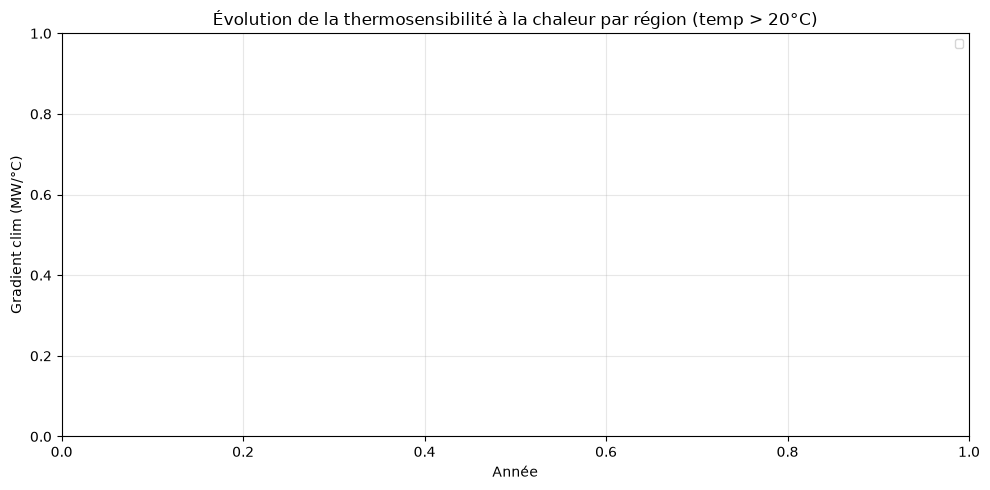

In [36]:
# Tendance temporelle, uniquement pour les régions estimables TOUTES les années
fiables = annuel.groupby('Région')['gradient_MW_par_C'].apply(lambda s: s.notna().all())
regions_fiables = fiables[fiables].index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
for region in regions_fiables:
    d = annuel[annuel['Région'] == region].sort_values('annee')
    ax.plot(d['annee'], d['gradient_MW_par_C'], marker='o', label=region)
ax.set_xlabel('Année')
ax.set_ylabel('Gradient clim (MW/°C)')
ax.set_title('Évolution de la thermosensibilité à la chaleur par région (temp > 20°C)')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Deux pièges d'interprétation :**
- **Le nord reste en NaN, c'est voulu.** Bretagne, Normandie, Hauts-de-France n'atteignent pas 30 jours > 20°C la plupart des années : la tendance ne se lit que pour le sud et l'Île-de-France.
- **Confondant météo vs adoption.** Un été très chaud (ex. 2022) a à la fois plus de jours chauds *et* un gradient plus raide (à 35°C on sollicite bien plus de climatiseurs qu'à 22°C — la convexité de la réponse). Un pic une année donnée ne prouve donc pas l'adoption : ça peut n'être que la chaleur. À présenter comme exploratoire, en mentionnant ce confondant. Pour isoler l'adoption, il faudrait une méthode plus lourde (gradient à température fixe, ou normalisation par le nombre de jours de canicule).

## 9. Limites à garder en tête

- **Faible pénétration de la clim** : le signal chaud reste modeste par rapport au chauffage (des centaines de MW/°C contre des milliers). C'est cohérent avec la réalité française et non un défaut de méthode.
- **Peu de jours chauds au nord** : les gradients des régions septentrionales reposent sur peu d'observations — d'où le grisage. Ne pas conclure sur ces régions.
- **Effet des étés récents** : les canicules de plus en plus fréquentes concentrent le signal sur les dernières années ; le gradient chaud est probablement en train d'augmenter dans le temps. Une piste d'extension serait de refaire la section 4 saison estivale par saison estivale (comme l'évolution hivernale), pour voir si la thermosensibilité chaude progresse — ce serait un résultat fort sur l'adaptation au changement climatique.
- **Température de base** : contrairement au froid (seuil physique 15°C bien établi par RTE), le seuil de déclenchement de la clim est moins standardisé. Tester la sensibilité au choix de `SEUIL_CHAUD` fait partie de l'exploration.